In [22]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [23]:
df=pd.read_csv("Housing.csv")
df.head(50)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [25]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [26]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

<Axes: ylabel='area'>

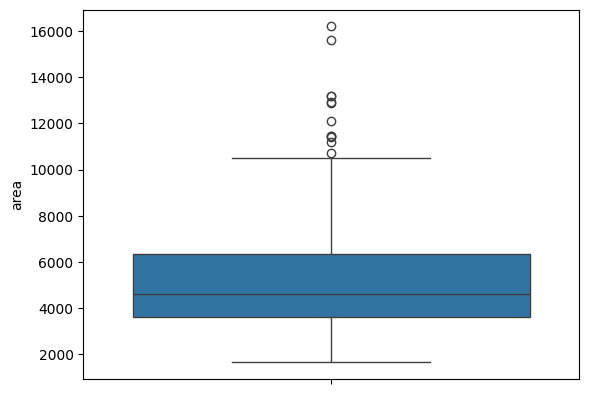

In [27]:
sns.boxplot(df['area'])

In [28]:
q1=df['area'].quantile(0.25)
q3=df['area'].quantile(0.75)

IQR=q3-q1

lwr=q1-1.5*IQR
upr=q3+1.5*IQR

df=df[(df['area']>=lwr) & (df['area']<=upr)]
df.head(100)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,6230000,5500,3,1,3,yes,no,no,no,no,1,yes,unfurnished
102,6195000,5500,3,2,4,yes,yes,no,no,yes,1,no,semi-furnished
103,6195000,6350,3,2,3,yes,yes,no,no,yes,0,no,furnished
104,6195000,5500,3,2,1,yes,yes,yes,no,no,2,yes,furnished


In [29]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.330000e+02,533.000000,533.000000,533.000000,533.000000,533.000000
mean,4.726995e+06,4980.724203,2.960600,1.287054,1.808630,0.684803
std,1.851251e+06,1855.265074,0.735988,0.500152,0.871953,0.859541
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3540.000000,2.000000,1.000000,1.000000,0.000000
50%,4.305000e+06,4500.000000,3.000000,1.000000,2.000000,0.000000
75%,5.652500e+06,6300.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,10500.000000,6.000000,4.000000,4.000000,3.000000


In [30]:
yes_no_catfeature = df[['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']].copy()

for col in yes_no_catfeature.columns:
    df[col] = df[col].map({'yes': 1, 'no': 0})

print("Encoded Categorical Features:")
print(df[yes_no_catfeature.columns].head(100))

Encoded Categorical Features:
     mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea
0           1          0         0                0                1         1
1           1          0         0                0                1         0
2           1          0         1                0                0         1
3           1          0         1                0                1         1
4           1          1         1                0                1         0
..        ...        ...       ...              ...              ...       ...
101         1          0         0                0                0         1
102         1          1         0                0                1         0
103         1          1         0                0                1         0
104         1          1         1                0                0         1
105         1          0         0                0                1         0

[100 rows x 6 columns

In [31]:
df.head(100)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,6230000,5500,3,1,3,1,0,0,0,0,1,1,unfurnished
102,6195000,5500,3,2,4,1,1,0,0,1,1,0,semi-furnished
103,6195000,6350,3,2,3,1,1,0,0,1,0,0,furnished
104,6195000,5500,3,2,1,1,1,1,0,0,2,1,furnished


In [32]:
from sklearn.preprocessing import  OrdinalEncoder

# Define the ordered categories
ordered_categories = ['furnished', 'semi-furnished', 'unfurnished']

# Create an OrdinalEncoder with the specified categories
encoder= OrdinalEncoder(categories=[ordered_categories])

# Fit and transform the 'furnishingstatus' column
df['furnishingstatus'] = encoder.fit_transform(df[['furnishingstatus']])

print("Encoded 'furnishingstatus':")

Encoded 'furnishingstatus':


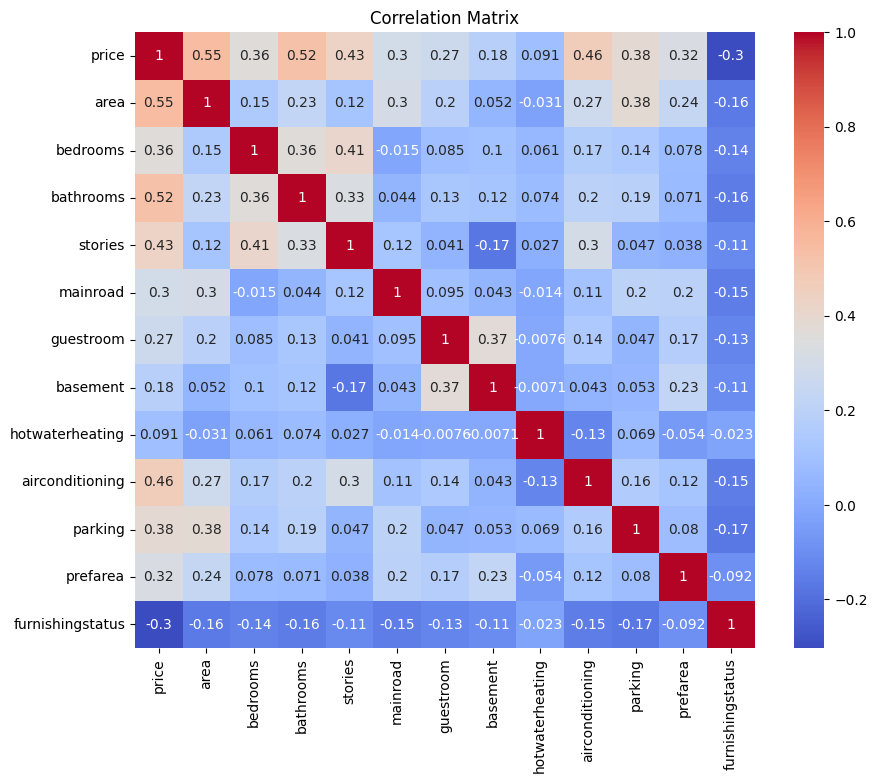

In [33]:
correlation_matrix = df.corr()


# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True,  cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [34]:
df = df.drop(['guestroom', 'basement', 'hotwaterheating'], axis=1)

In [35]:
x = df.drop(['price'], axis=1)
y= df['price']

In [36]:


# Split into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=35)

# Create the model
model = LinearRegression()

# Train the model using the training sets
model.fit(x_train, y_train)

LinearRegression()

In [37]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 2.70286653e+02  1.43483152e+05  1.12380572e+06  3.60805112e+05
  4.86456767e+05  8.35404413e+05  2.98769258e+05  7.43379463e+05
 -2.88715434e+05]
Intercept: 156723.69170439523


In [38]:
y_pred = model.predict(x_test)

In [39]:
r2=r2_score(y_pred,y_test)
r2

0.7275173446217089

In [40]:
mse = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mse)

Mean Absolute Error: 694542.4629027456


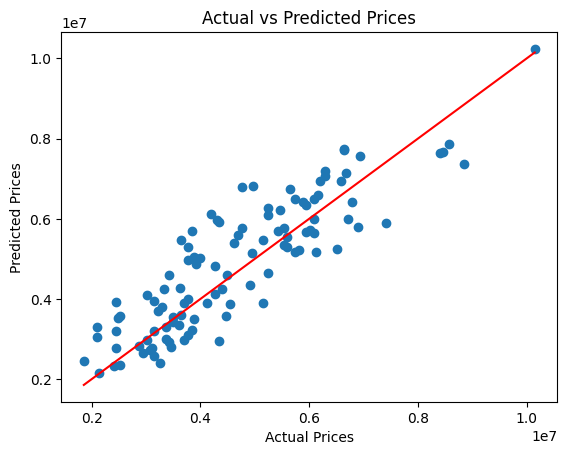

In [41]:

plt.scatter(y_test, y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Line for perfect predictions
plt.show()

In [43]:
house_price = {
    'area': 5500,
    'bedrooms': 3,
    'bathrooms': 1,
    'stories': 3,
    'mainroad': 1,
    'airconditioning': 0,
    'parking': 1,
    'prefarea': 1,
    'furnishingstatus': 0
}

# Wrap the dictionary in a list to create a single-row DataFrame
df = pd.DataFrame([house_price])
# Predict the price for the new house
predicted_price = model.predict(df)
print("Predicted Price for the new house:", predicted_price[0])

Predicted Price for the new house: 5808576.286378416
